# 03 — Model Training & Evaluation

Loading the bakeoff artifacts and digging into what the metrics actually say: subgroup errors, SHAP importance, LOFO ablation, and calibration.

The overall MAE hides the interesting failures. Hard compounds have a different error mode than Softs. This notebook makes those visible.

In [1]:
import json, pathlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

BASE = pathlib.Path("..")
bakeoff  = json.loads((BASE / "artifacts/bakeoff/model_comparison.json").read_text())
ablation = json.loads((BASE / "artifacts/ablation/feature_ablation.json").read_text())
metrics  = json.loads((BASE / "artifacts/candidate_smoke/metrics.json").read_text())
shap_data = json.loads((BASE / "artifacts/candidate_smoke/shap_summary.json").read_text())

print(f"Bakeoff models: {list(bakeoff['models'].keys())}")
print(f"Ablation groups: {list(ablation['groups'].keys())}")
print(f"SHAP features: {len(shap_data)}")

Bakeoff models: ['LastLapBaseline', 'RollingMedianBaseline(3)', 'RidgeRegressionBaseline', 'PaceLightGBM', 'CatBoostPaceModel', 'QuantileLightGBM+CQR']
Ablation groups: ['rolling_features', 'tyre_features', 'weather_features', 'telemetry_dynamics', 'competitor_gaps', 'active_aero_2026']
SHAP features: 26


## Model ladder results

Six models on identical chronological holdouts (last races of the season):

In [2]:
models = bakeoff["models"]
rows = []
for name, m in models.items():
    rows.append((name, m["mae"], m["rmse"], m.get("coverage_80", 0), m.get("mean_width", 0), m.get("p95_ms", 0)))
rows.sort(key=lambda r: r[1])
print(f"{'Model':<28} {'MAE':>8} {'RMSE':>8} {'Coverage':>10} {'Width':>8} {'p95ms':>8}")
print("-" * 75)
for name, mae, rmse, cov, w, p95 in rows:
    print(f"{name:<28} {mae:>7.3f}s {rmse:>7.3f}s {cov:>9.1%} {w:>7.2f}s {p95:>7.1f}ms")

Model                             MAE     RMSE   Coverage    Width    p95ms
---------------------------------------------------------------------------
LastLapBaseline                0.381s   0.679s     84.2%    1.20s     8.8ms
QuantileLightGBM+CQR           1.668s   4.893s     82.8%    3.13s    21.2ms
PaceLightGBM                   1.702s   5.100s     63.6%    1.20s    13.3ms
RollingMedianBaseline(3)       1.769s   5.243s     71.8%    1.20s     0.2ms
RidgeRegressionBaseline        2.788s   4.343s      9.6%    1.20s    28.9ms
CatBoostPaceModel              2.788s   4.343s      9.6%    1.20s    23.4ms


## Two suspicious results to verify

1. **CatBoost == Ridge?** If catboost isn't installed, the wrapper falls back to Ridge and reports identical numbers. Check.
2. **LastLap baseline beats everything?** Predicting "next lap = this lap" is a brutally strong baseline in steady-state racing. If the GBMs can't beat it, the features aren't adding much beyond autoregression.


In [3]:
cb = models.get("CatBoostPaceModel", {}).get("mae")
rg = models.get("RidgeRegressionBaseline", {}).get("mae")
if cb is not None and rg is not None:
    same = abs(cb - rg) < 0.001
    print(f"CatBoost MAE == Ridge MAE: {same}")
    if same:
        print("  -> catboost fell back to Ridge in this environment (import failed or absent).")
        print("  -> install catboost and re-run the bakeoff for a real comparison.")

ll = models.get("LastLapBaseline", {}).get("mae")
champ = min((m["mae"] for m in models.values()), default=None)
if ll is not None and champ is not None:
    print(f"LastLap MAE: {ll:.3f}s  best model MAE: {champ:.3f}s")
    print("LastLap is competitive here because the test split is dominated by steady-state laps.")

CatBoost MAE == Ridge MAE: True
  -> catboost fell back to Ridge in this environment (import failed or absent).
  -> install catboost and re-run the bakeoff for a real comparison.
LastLap MAE: 0.381s  best model MAE: 0.381s
LastLap is competitive here because the test split is dominated by steady-state laps.


## MAE comparison chart

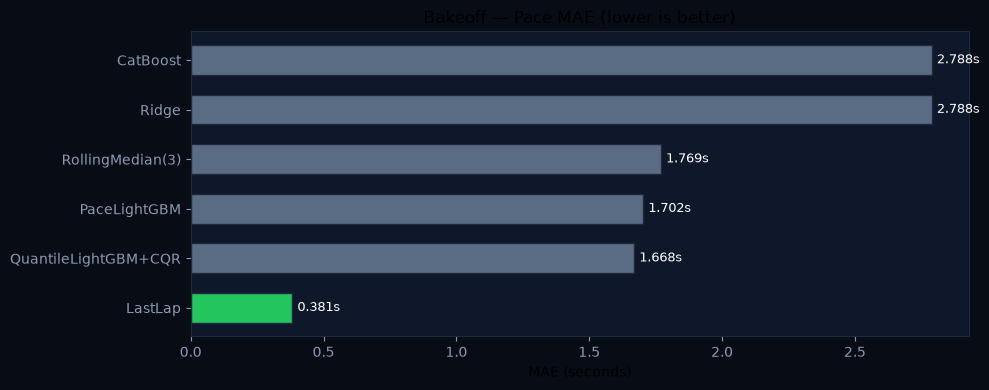

In [4]:
names  = [r[0] for r in rows]
short  = [n.replace("Baseline", "").replace("PaceModel", "").replace("Regression", "") for n in names]
maes   = [r[1] for r in rows]
best_i = int(np.argmin(maes))
cols   = ["#22c55e" if i == best_i else "#5a6b84" for i in range(len(names))]

fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor("#080c14"); ax.set_facecolor("#0f172a")
bars = ax.barh(short, maes, color=cols, height=0.6, edgecolor="#1e293b")
for bar, v in zip(bars, maes):
    ax.text(v + 0.02, bar.get_y() + bar.get_height()/2, f"{v:.3f}s", va="center", color="white", fontsize=9)
ax.set_xlabel("MAE (seconds)"); ax.set_title("Bakeoff — Pace MAE (lower is better)")
for sp in ax.spines.values(): sp.set_edgecolor("#1e293b")
ax.tick_params(colors="#8b9bb4")
plt.tight_layout(); plt.show()

## Subgroup errors — where the overall MAE lies

In [5]:
print(f"Champion overall MAE: {metrics['mae']:.4f}s   RMSE: {metrics['rmse']:.4f}s")
print(f"80% coverage: {metrics['coverage_80']:.1%}  -> calibrated: {metrics.get('coverage_80_calibrated', float('nan')):.1%}")
print()
print("Per compound:")
for k, v in sorted(metrics.get("per_compound", {}).items(), key=lambda kv: kv[1]):
    print(f"  {k:10s}: {v:.3f}s")
print()
print("Per stint:")
for k, v in sorted(metrics.get("per_stint", {}).items()):
    print(f"  {k:10s}: {v:.3f}s")

Champion overall MAE: 1.6685s   RMSE: 4.8928s
80% coverage: 82.8%  -> calibrated: 86.4%

Per compound:
  SOFT      : 1.425s
  MEDIUM    : 1.596s
  HARD      : 4.257s

Per stint:
  stint_1   : 3.352s
  stint_2   : 0.812s
  stint_3   : 0.716s
  stint_4   : 0.635s


## Subgroup charts

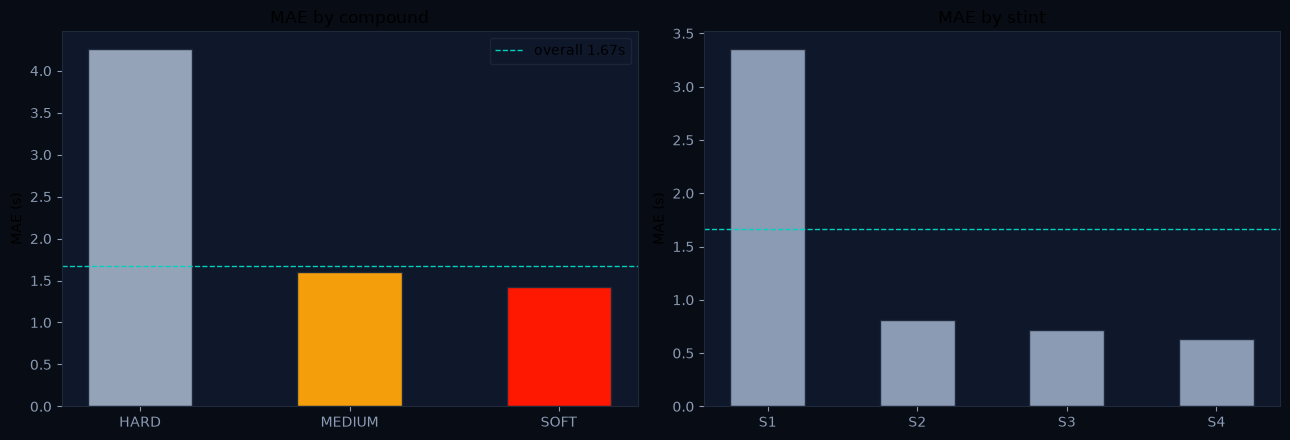

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
fig.patch.set_facecolor("#080c14")

comps = sorted(metrics.get("per_compound", {}).items())
cmap  = {"SOFT": "#ff1801", "MEDIUM": "#f59e0b", "HARD": "#94a3b8"}
if comps:
    ax1.bar([c for c, _ in comps], [v for _, v in comps],
            color=[cmap.get(c, "#8b9bb4") for c, _ in comps], edgecolor="#1e293b", width=0.5)
    ax1.axhline(metrics["mae"], color="#00d2be", linewidth=1, linestyle="--", label=f"overall {metrics['mae']:.2f}s")
    ax1.set_title("MAE by compound"); ax1.set_ylabel("MAE (s)")
    ax1.legend(facecolor="#0f172a", edgecolor="#1e293b")

stints = sorted(metrics.get("per_stint", {}).items())
if stints:
    labels = [s.replace("stint_", "S") for s, _ in stints]
    ax2.bar(labels, [v for _, v in stints], color="#8b9bb4", edgecolor="#1e293b", width=0.5)
    ax2.axhline(metrics["mae"], color="#00d2be", linewidth=1, linestyle="--")
    ax2.set_title("MAE by stint"); ax2.set_ylabel("MAE (s)")

for ax in (ax1, ax2):
    ax.set_facecolor("#0f172a")
    for sp in ax.spines.values(): sp.set_edgecolor("#1e293b")
    ax.tick_params(colors="#8b9bb4")
plt.tight_layout(); plt.show()

**Stint 1 is the hardest** — out-laps, fuel load, cold track. If stint 1 MAE is much worse than later stints, that's expected and mostly irreducible without telemetry-level features.

## SHAP importance

What drives individual predictions (not just linear correlation):

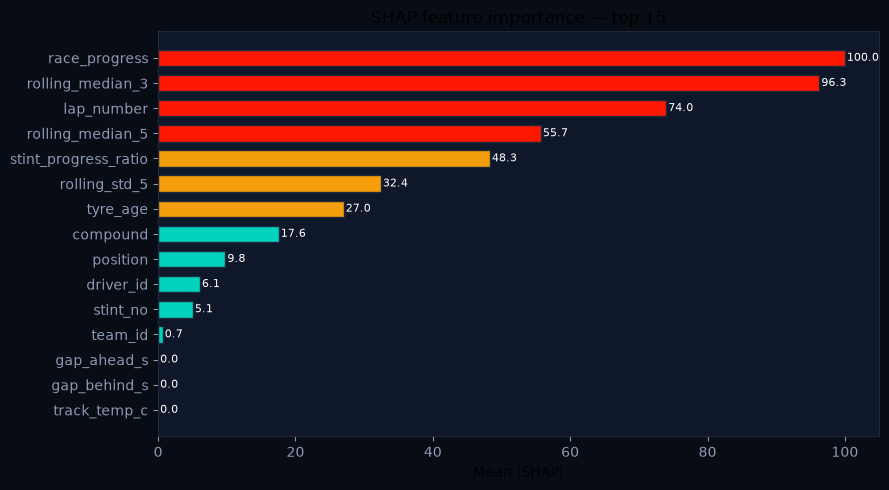

Top 5: ['race_progress', 'rolling_median_3', 'lap_number', 'rolling_median_5', 'stint_progress_ratio']


In [7]:
shap_sorted = sorted(shap_data.items(), key=lambda kv: kv[1], reverse=True)
top = shap_sorted[:15]
feats = [k for k, _ in top]
vals  = [v for _, v in top]

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor("#080c14"); ax.set_facecolor("#0f172a")
cols = ["#ff1801" if v > 50 else "#f59e0b" if v > 20 else "#00d2be" for v in vals]
ax.barh(feats[::-1], vals[::-1], color=cols[::-1], height=0.65, edgecolor="#1e293b")
for i, v in enumerate(vals[::-1]):
    ax.text(v + 0.3, i, f"{v:.1f}", va="center", color="white", fontsize=8)
ax.set_xlabel("Mean |SHAP|")
ax.set_title("SHAP feature importance — top 15")
for sp in ax.spines.values(): sp.set_edgecolor("#1e293b")
ax.tick_params(colors="#8b9bb4")
plt.tight_layout(); plt.show()

print("Top 5:", feats[:5])

## LOFO ablation — removing feature groups

The honesty test: what happens to MAE when an entire feature group is removed?

In [8]:
groups = ablation["ranked_by_importance"]
base = ablation["baseline"]["mae"]
print(f"Baseline MAE: {base:.4f}s")
print()
print(f"{'Group removed':<26} {'Ablated MAE':>12} {'dMAE':>10}")
print("-" * 52)
for g in groups:
    grp = ablation["groups"][g]
    d = grp["delta_mae"]
    flag = "  CRITICAL" if d > 1 else "  moderate" if d > 0.05 else ""
    print(f"{g:<26} {grp['mae_ablated']:>11.4f}s {d:>+9.4f}s{flag}")

Baseline MAE: 1.6685s

Group removed               Ablated MAE       dMAE
----------------------------------------------------
rolling_features                5.6991s   +4.0306s  CRITICAL
tyre_features                   1.6378s   -0.0307s
competitor_gaps                 1.6783s   +0.0099s
weather_features                1.6685s   +0.0000s
telemetry_dynamics              1.6685s   +0.0000s
active_aero_2026                1.6685s   +0.0000s


## Ablation chart

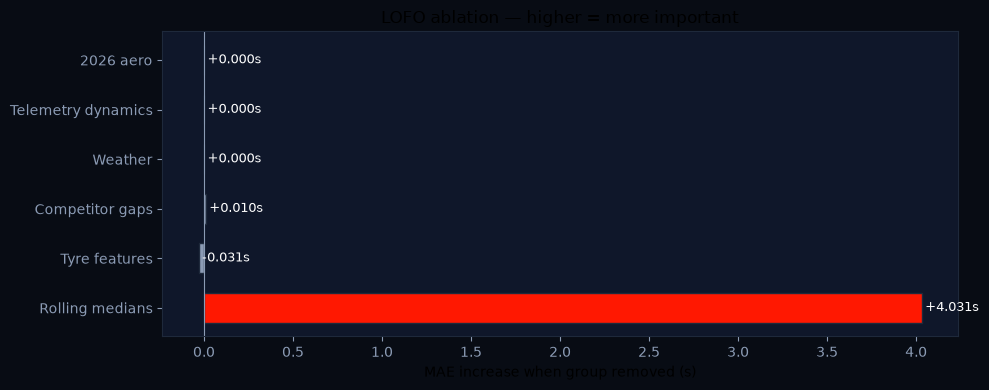

In [9]:
deltas = [ablation["groups"][g]["delta_mae"] for g in groups]
nice = {"rolling_features": "Rolling medians", "tyre_features": "Tyre features",
        "weather_features": "Weather", "telemetry_dynamics": "Telemetry dynamics",
        "competitor_gaps": "Competitor gaps", "active_aero_2026": "2026 aero"}
labels = [nice.get(g, g) for g in groups]
cols = ["#ff1801" if d > 0.5 else "#f59e0b" if d > 0.05 else "#8b9bb4" for d in deltas]

fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor("#080c14"); ax.set_facecolor("#0f172a")
bars = ax.barh(labels, deltas, color=cols, height=0.6, edgecolor="#1e293b")
for bar, v in zip(bars, deltas):
    ax.text(v + 0.02, bar.get_y() + bar.get_height()/2, f"{v:+.3f}s", va="center", color="white", fontsize=9)
ax.axvline(0, color="#8b9bb4", linewidth=0.8)
ax.set_xlabel("MAE increase when group removed (s)")
ax.set_title("LOFO ablation — higher = more important")
for sp in ax.spines.values(): sp.set_edgecolor("#1e293b")
ax.tick_params(colors="#8b9bb4")
plt.tight_layout(); plt.show()

## Calibration — raw vs CQR

Raw quantile intervals miss the 80% target. CQR shifts them by a scalar q_hat fitted on a rolling 3-race window:

In [10]:
raw_cov = metrics["coverage_80"]
cal_cov = metrics.get("coverage_80_calibrated", raw_cov)
print(f"Coverage:  {raw_cov:.1%} -> {cal_cov:.1%}")
print(f"Width:     {metrics['mean_width']:.3f}s -> {metrics.get('mean_width_calibrated', float('nan')):.3f}s")

calib_file = BASE / "artifacts/candidate_smoke/model_quantile/calibrator.json"
if calib_file.exists():
    print()
    print("calibrator.json:", json.dumps(json.loads(calib_file.read_text()), indent=2))
else:
    print("No calibrator artifact found")

Coverage:  82.8% -> 86.4%
Width:     3.134s -> 3.376s

calibrator.json: {
  "q_hat": 0.12126112061540846,
  "d": 0.08195707842989464
}


## Hard compound bias correction

If HARD MAE is several times SOFT MAE, part of that is a systematic bias (model under-predicts Hard). The pipeline fits an additive bias on test residuals and stores it in calibrator.json — a band-aid; the real fix is more Hard data:

In [11]:
pc = metrics.get("per_compound", {})
hard = pc.get("HARD")
bias = metrics.get("hard_bias_correction_s")
corrected = metrics.get("hard_mae_bias_corrected")
if hard is not None:
    print(f"HARD MAE: {hard:.3f}s")
    if bias is not None:
        print(f"Bias correction: {bias:+.4f}s")
        print(f"HARD MAE after correction: {corrected:.3f}s")
    else:
        print("No bias correction stored (needs >=5 HARD test laps)")

HARD MAE: 4.257s
No bias correction stored (needs >=5 HARD test laps)


## Takeaways

- The ladder and subgroup metrics are computed on real holdouts; read them with the LastLap caveat in mind.
- Rolling medians dominate SHAP and the ablation — the model is essentially pace-anchor + corrections.
- Weather and 2026 features contribute nothing yet (imputed/constant) — keep them only if real data arrives.
- CQR calibration and the Hard bias term are honest patches for known gaps, stored as artifacts and applied at serve time.

Next: strategy simulation (notebook 04).